<h1 style="background-color:black;font-family:newtimeroman;color:skyblue;font-size:350%;text-align:center;border-radius: 15px 50px;">Detecting Fraud in E-Commerce Transactions</h1>

Online retail has made it effortless to buy almost anything with a few taps, and that same
convenience has made e-commerce a prime target for fraud. Stolen cards, account takeovers and
"friendly fraud" chargebacks cost merchants tens of billions of dollars every year, and every
false decline also costs a merchant a legitimate sale. A good fraud model has to catch the
rare bad transaction without punishing the overwhelming majority of honest customers.

In this notebook we work with a dataset of **~1.47 million e-commerce transactions**, of which
about **5% are labelled fraudulent**. Each row describes a single transaction: how much was
spent, how it was paid for, what was bought, who the customer is, which device they used, and
some account metadata (how old the account is, what hour the purchase happened, etc).

The workflow mirrors a typical applied fraud-analytics project:
1. **Data loading & cleaning** — look for missing values, duplicates and suspicious entries.
2. **Exploratory data analysis (EDA)** — find out which factors actually separate fraud from genuine activity.
3. **Feature engineering** — turn those findings into model-ready features.
4. **Visualization** — see the "fingerprints" fraud leaves behind.
5. **Machine learning** — train and compare Logistic Regression, K-Nearest Neighbors, Random Forest and
   XGBoost classifiers, and evaluate them with metrics suited to a heavily imbalanced problem
   (precision/recall, ROC-AUC, and average precision rather than plain accuracy).

<h3 style="background-color:black;font-family:newtimeroman;color:skyblue;font-size:200%;text-align:center;border-radius: 15px 50px;">Libraries and Utilities</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc,
                              average_precision_score, precision_recall_curve)

sns.set_style("darkgrid")
plt.rcParams["figure.facecolor"] = "white"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 20)


<h3 style="background-color:black;font-family:newtimeroman;color:skyblue;font-size:200%;text-align:center;border-radius: 15px 50px;">Data Loading</h3>

In [2]:
df = pd.read_csv("Fraudulent_E-Commerce_Transaction_Data.csv")
print("Shape:", df.shape)
df.head()


Shape: (1472952, 16)


,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


Quick look at data types and a sanity check for missing values, since (as with most fraud datasets) the absence of an explicit NaN doesn't rule out values like 0 or -1 standing in for a missing entry.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472952 entries, 0 to 1472951
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction ID      1472952 non-null  object 
 1   Customer ID         1472952 non-null  object 
 2   Transaction Amount  1472952 non-null  float64
 3   Transaction Date    1472952 non-null  object 
 4   Payment Method      1472952 non-null  object 
 5   Product Category    1472952 non-null  object 
 6   Quantity            1472952 non-null  int64  
 7   Customer Age        1472952 non-null  int64  
 8   Customer Location   1472952 non-null  object 
 9   Device Used         1472952 non-null  object 
 10  IP Address          1472952 non-null  object 
 11  Shipping Address    1472952 non-null  object 
 12  Billing Address     1472952 non-null  object 
 13  Is Fraudulent       1472952 non-null  int64  
 14  Account Age Days    1472952 non-null  int64  
 15  Transaction Hou

* value_counts(): Counts the exact number of transactions labeled as fraud versus legitimate.
* value_counts(normalize=True): Shows the percentage split of the classes to highlight the severity of data imbalance

In [4]:
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nFraud label distribution:")
print(df["Is Fraudulent"].value_counts())
print(df["Is Fraudulent"].value_counts(normalize=True).rename("proportion"))


Total missing values: 0
Duplicate rows: 0

Fraud label distribution:
Is Fraudulent
0    1399114
1      73838
Name: count, dtype: int64
Is Fraudulent
0    0.949871
1    0.050129
Name: proportion, dtype: float64


<h3 style="background-color:black;font-family:newtimeroman;color:skyblue;font-size:200%;text-align:center;border-radius: 15px 50px;">Data Cleaning</h3>

<i><b>Is `Customer Age` always sensible?</b></i> A quick look at the summary statistics shows a minimum age below zero, which is impossible &mdash; almost certainly a data-entry artefact rather than a genuine signal. We don't drop these rows (there's no reason to believe they are more or less likely to be fraud), but we do clean the feature by taking the absolute value so it doesn't confuse a distance- or split-based model.

In [5]:
print(df["Customer Age"].describe())
n_negative = (df["Customer Age"] < 0).sum()
print(f"\nNumber of negative ages: {n_negative} ({n_negative/len(df):.3%} of rows)")

df["Customer Age"] = df["Customer Age"].abs()


count    1.472952e+06
mean     3.451208e+01
std      1.000313e+01
min     -1.600000e+01
25%      2.800000e+01
50%      3.500000e+01
75%      4.100000e+01
max      8.600000e+01
Name: Customer Age, dtype: float64

Number of negative ages: 258 (0.018% of rows)


<i><b>Are `Transaction ID`, `Customer ID`, `IP Address` useful as model features?</b></i> These are high-cardinality identifiers (almost one unique value per row, or per customer) with no inherent ordering. Left as-is they add noise and blow up dimensionality without giving a tree- or distance-based model anything generalizable to learn, so — much like the account names in a payments dataset — we drop them from the modelling feature set below, after using the address fields once to engineer a shipping/billing mismatch flag.

<h3 style="background-color:black;font-family:newtimeroman;color:skyblue;font-size:200%;text-align:center;border-radius: 15px 50px;">Exploratory Data Analysis</h3>

<i><b>Do payment method, product category or device tell us anything about fraud risk?</b></i> These are the three obvious categorical fields, so we start there.

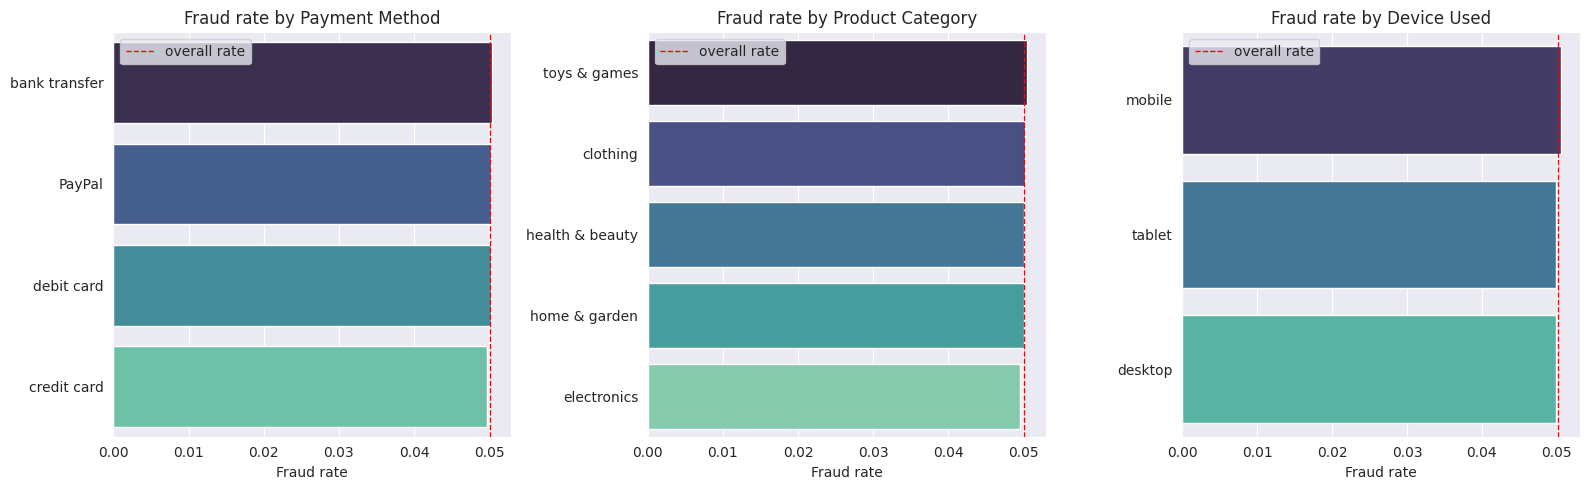

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["Payment Method", "Product Category", "Device Used"]):
    rates = df.groupby(col)["Is Fraudulent"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index, hue=rates.index, legend=False,
                palette="mako", ax=ax)
    ax.axvline(df["Is Fraudulent"].mean(), color="red", linestyle="--", linewidth=1,
               label="overall rate")
    ax.set_title(f"Fraud rate by {col}")
    ax.set_xlabel("Fraud rate")
    ax.set_ylabel("")
    ax.legend()
plt.tight_layout()
plt.show()


All three sit within a fraction of a percentage point of the overall 5.0% fraud rate. On their own, payment method, product category and device used are essentially uninformative — fraudsters use the same mix of payment methods, products and devices as everyone else. They may still add a little value in combination with other features, so we'll keep them as categorical inputs, but we shouldn't expect them to carry the model.

<i><b>Does account age matter?</b></i> Newly created accounts are a classic fraud signal — stolen identities and disposable accounts don't have a history.

Account Age Days
0-7d        0.222818
8-30d       0.224132
31-90d      0.030603
91-180d     0.030528
181-365d    0.030814
Name: Is Fraudulent, dtype: float64


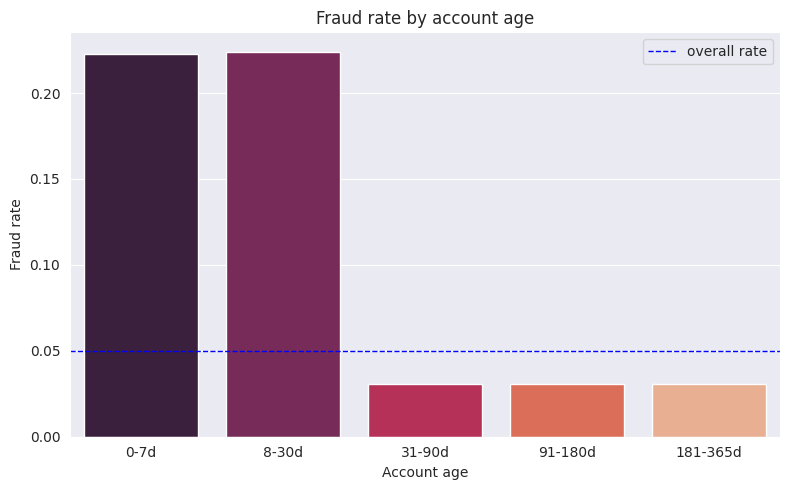

In [7]:
acct_bins = pd.cut(df["Account Age Days"], bins=[0, 7, 30, 90, 180, 365],
                    labels=["0-7d", "8-30d", "31-90d", "91-180d", "181-365d"])
fraud_by_acct = df.groupby(acct_bins, observed=True)["Is Fraudulent"].mean()
print(fraud_by_acct)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=fraud_by_acct.index, y=fraud_by_acct.values, hue=fraud_by_acct.index,
            legend=False, palette="rocket", ax=ax)
ax.axhline(df["Is Fraudulent"].mean(), color="blue", linestyle="--", linewidth=1, label="overall rate")
ax.set_title("Fraud rate by account age")
ax.set_ylabel("Fraud rate")
ax.set_xlabel("Account age")
ax.legend()
plt.tight_layout()
plt.show()


This is a real signal: accounts younger than 30 days show a fraud rate around **22%**, roughly seven times higher than accounts older than a month (~3%). Account age looks like one of the most useful features in the dataset.

<i><b>Is fraud more common at certain hours of the day?</b></i>

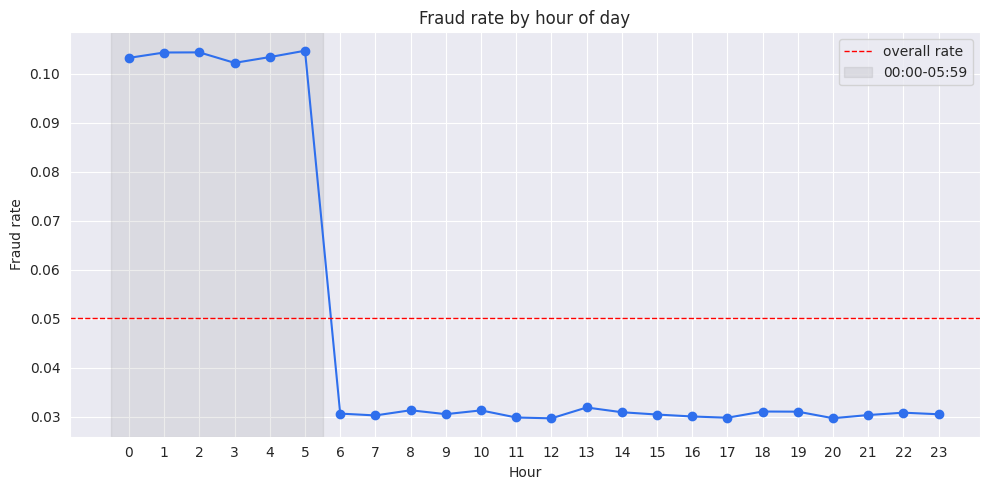

In [8]:
fraud_by_hour = df.groupby("Transaction Hour")["Is Fraudulent"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fraud_by_hour.index, fraud_by_hour.values, marker="o", color="#2f6fed")
ax.axhline(df["Is Fraudulent"].mean(), color="red", linestyle="--", linewidth=1, label="overall rate")
ax.axvspan(-0.5, 5.5, color="grey", alpha=0.15, label="00:00-05:59")
ax.set_title("Fraud rate by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("Fraud rate")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()


Fraud rate roughly triples during the overnight window (00:00-05:59, ~10%) compared with daytime hours (~3%) — consistent with fraudulent activity happening while a legitimate account holder is asleep and less likely to notice or intervene.

<i><b>Does the transaction amount itself differ between fraud and genuine transactions?</b></i>

In [9]:
print(df.groupby("Is Fraudulent")["Transaction Amount"].describe())


                   count        mean         std   min     25%      50%  \
Is Fraudulent                                                             
0              1399114.0  209.824851  199.883998  10.0   67.35  148.510   
1                73838.0  547.820193  770.022697  10.0  106.37  256.185   

                  75%       max  
Is Fraudulent                    
0              287.10   3570.78  
1              634.61  12701.75  


Fraudulent transactions average    **~548** versus  **~210** for genuine ones, and the largest fraudulent transaction **~12,702** is far above the largest genuine one **~3,571**. Transaction amount is another strong candidate feature.
* <i><b>What about the shipping vs. billing address?</b></i>    
 A common fraud heuristic is 'ship-to' and 'bill-to' addresses not matching.

In [10]:
addr_mismatch = df["Shipping Address"] != df["Billing Address"]
print("Share of transactions with mismatched shipping/billing address:", addr_mismatch.mean())
print(df.groupby(addr_mismatch)["Is Fraudulent"].mean())


Share of transactions with mismatched shipping/billing address: 0.10015465541307524
False    0.050161
True     0.049843
Name: Is Fraudulent, dtype: float64


Address mismatch turns out **not** to separate fraud from genuine activity here (both classes mismatch about 10% of the time) — a reminder that intuitive fraud heuristics still need to be checked against the data rather than assumed. We won't rely on this feature.

<h3 style="background-color:black;font-family:newtimeroman;color:skyblue;font-size:200%;text-align:center;border-radius: 15px 50px;">Feature Engineering</h3>

Guided by the EDA above, we turn the strongest patterns into explicit model features rather than hoping a model discovers them on its own:
* **`Is New Account`** — account age of 30 days or less (captures the ~7x jump in fraud rate).
- **`Is Night`** — transaction hour between 00:00 and 05:59 (captures the overnight spike).
- **`Amount Per Item`** — transaction amount divided by quantity, since a fraudster running up one expensive item looks different from a large legitimate bulk order.
- **`Customer Age`** — already cleaned to remove impossible negative values.

We drop the free-text identifier and address columns (`Transaction ID`, `Customer ID`, `Customer Location`, `IP Address`, `Shipping Address`, `Billing Address`, `Transaction Date`) since they are either pure identifiers or, in the case of address matching, were shown above not to carry signal.

In [11]:
features = df.copy()
features["Is New Account"] = (features["Account Age Days"] <= 30).astype(int)
features["Is Night"] = features["Transaction Hour"].between(0, 5).astype(int)
features["Amount Per Item"] = features["Transaction Amount"] / features["Quantity"]

drop_cols = ["Transaction ID", "Customer ID", "Customer Location", "IP Address",
             "Shipping Address", "Billing Address", "Transaction Date"]
features = features.drop(columns=drop_cols)

categorical_cols = ["Payment Method", "Product Category", "Device Used"]
features = pd.get_dummies(features, columns=categorical_cols, drop_first=False)

print("Final feature matrix shape:", features.shape)
features.head()


Final feature matrix shape: (1472952, 21)


,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour,Is New Account,Is Night,Amount Per Item,Payment Method_PayPal,...,Payment Method_credit card,Payment Method_debit card,Product Category_clothing,Product Category_electronics,Product Category_health & beauty,Product Category_home & garden,Product Category_toys & games,Device Used_desktop,Device Used_mobile,Device Used_tablet
0,58.09,1,17,0,30,5,1,1,58.090,False,...,False,False,False,True,False,False,False,False,False,True
1,389.96,2,40,0,72,8,0,0,194.980,False,...,False,True,False,True,False,False,False,True,False,False
2,134.19,2,22,0,63,3,0,1,67.095,True,...,False,False,False,False,False,True,False,False,False,True
3,226.17,5,31,0,124,20,0,0,45.234,False,...,False,False,True,False,False,False,False,True,False,False
4,121.53,2,51,0,158,5,0,1,60.765,False,...,False,False,True,False,False,False,False,False,False,True


<h3 style="background-color:black;font-family:newtimeroman;color:skyblue;font-size:200%;text-align:center;border-radius: 15px 50px;">Data Visualization</h3>

A correlation heatmap of the engineered numeric features helps check for redundancy before modelling, and confirms `Account Age Days`, `Is New Account` and `Is Night` line up with the label as expected from the EDA.

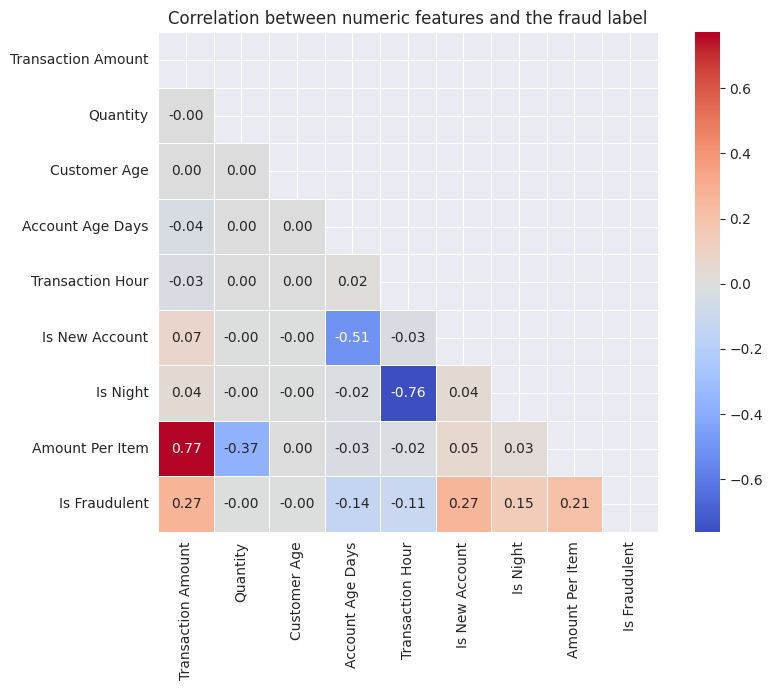

In [12]:
numeric_cols = ["Transaction Amount", "Quantity", "Customer Age", "Account Age Days",
                "Transaction Hour", "Is New Account", "Is Night", "Amount Per Item", "Is Fraudulent"]
corr = features[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation between numeric features and the fraud label")
plt.tight_layout()
plt.show()


Distribution plots make the amount and account-age separation between the two classes visible directly, echoing what we already found while grouping.

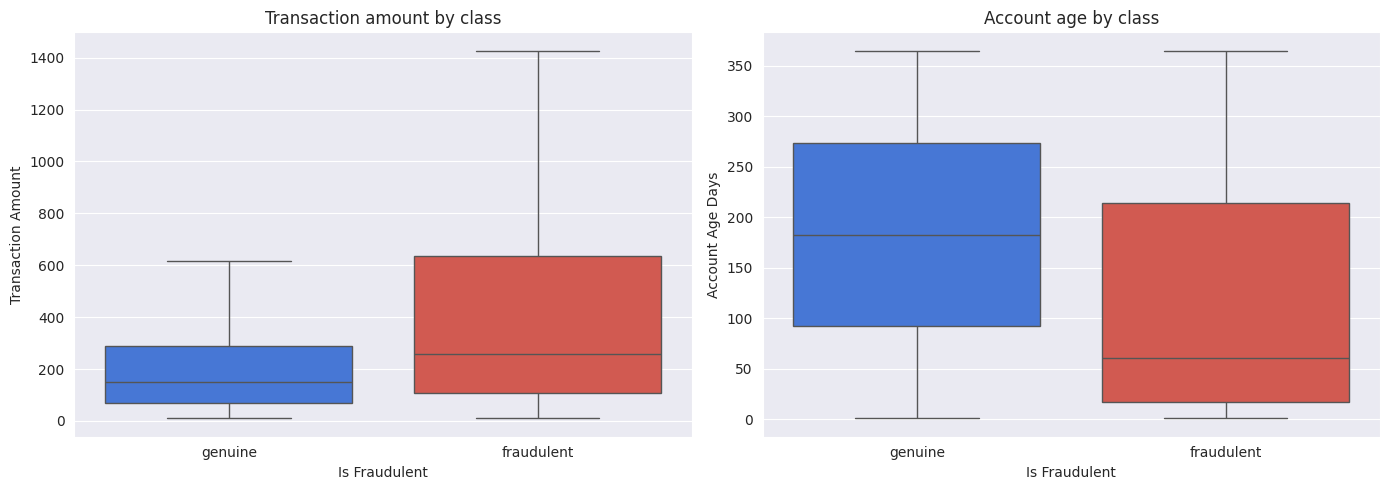

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=features, x="Is Fraudulent", y="Transaction Amount", hue="Is Fraudulent",
            legend=False, palette=["#2f6fed", "#e6483c"], showfliers=False, ax=axes[0])
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["genuine", "fraudulent"])
axes[0].set_title("Transaction amount by class")

sns.boxplot(data=features, x="Is Fraudulent", y="Account Age Days", hue="Is Fraudulent",
            legend=False, palette=["#2f6fed", "#e6483c"], showfliers=False, ax=axes[1])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["genuine", "fraudulent"])
axes[1].set_title("Account age by class")

plt.tight_layout()
plt.show()


<i><b>Dispersion over time</b></i>

The plots below recreate the 'fingerprint' style of visualization — plotting individual transactions as a jittered strip for each class, colored by a categorical field. A random sample of 150,000 transactions is used to keep the plot readable and fast to render.

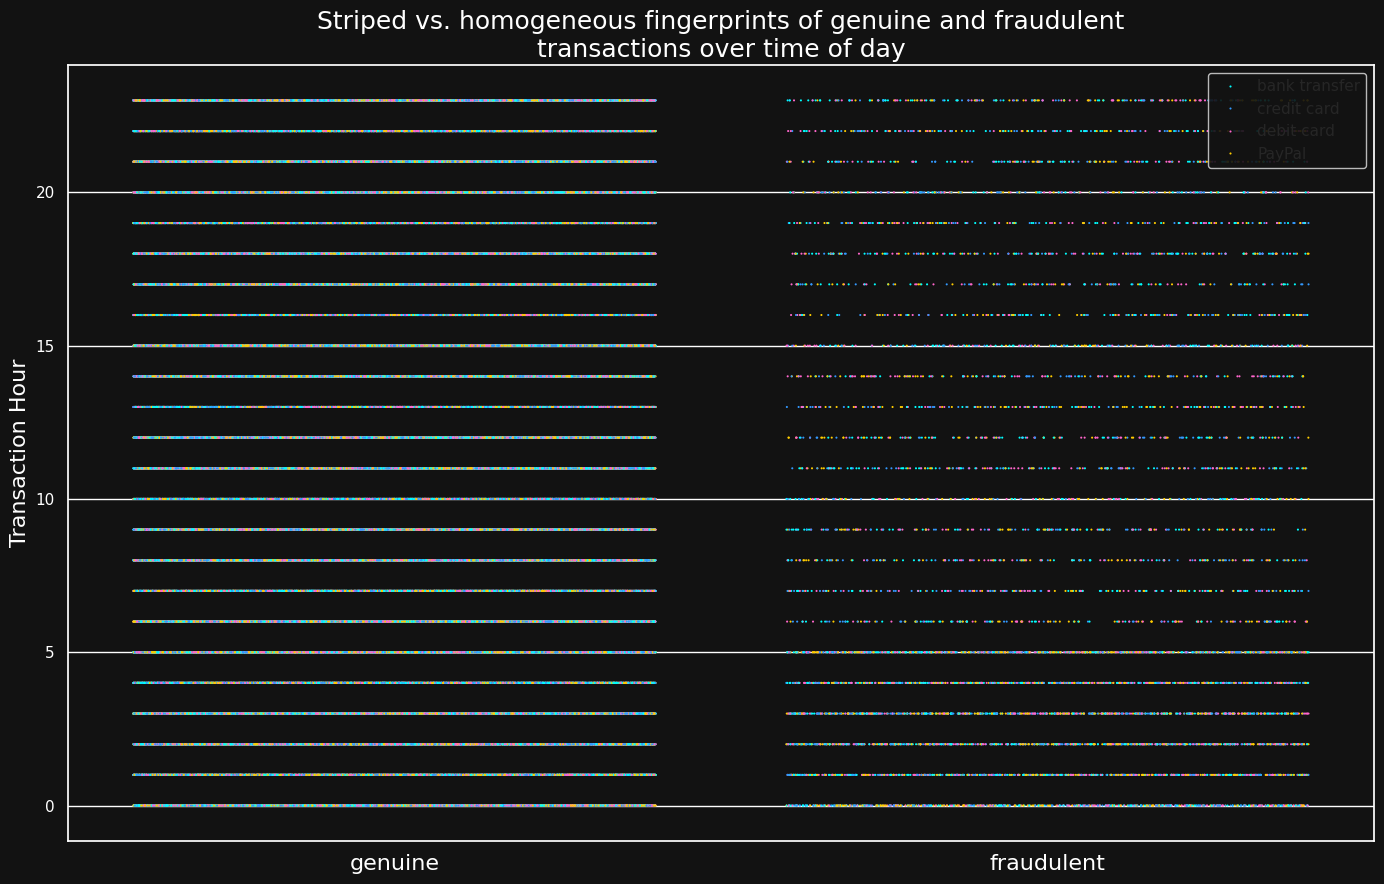

In [14]:
plot_sample = df.sample(n=150_000, random_state=RANDOM_STATE)

def plot_strip(x, y, hue, palette, figsize=(14, 9)):
    sns.set(rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212"})
    fig = plt.figure(figsize=figsize)
    ax = sns.stripplot(x=x, y=y, hue=hue, jitter=0.4, marker=".", size=3, palette=palette)
    ax.set_xlabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["genuine", "fraudulent"], fontsize=16, color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("white")
    ax.legend(loc="upper right", framealpha=0.9)
    return ax

ax = plot_strip(plot_sample["Is Fraudulent"], plot_sample["Transaction Hour"],
                 plot_sample["Payment Method"], ["#00FFFF", "#3399FF", "#FF66CC", "#FFCC00"])
ax.set_ylabel("Transaction Hour", size=16, color="white")
ax.set_title("Striped vs. homogeneous fingerprints of genuine and fraudulent\ntransactions over time of day",
             size=18, color="white")
plt.tight_layout()
plt.show()

sns.set(rc={"axes.facecolor": "white", "figure.facecolor": "white"})  # reset for later cells


here **both** classes are dispersed across all 24 hours, since real shoppers don't transact at fixed clock-hours. But look closely at the *density*: fraudulent points bunch up more heavily in the overnight band (hours 0-5), consistent with the ~10% vs ~3% fraud-rate gap found earlier — the fingerprint is subtler here

<i><b>Dispersion over amount</b></i>

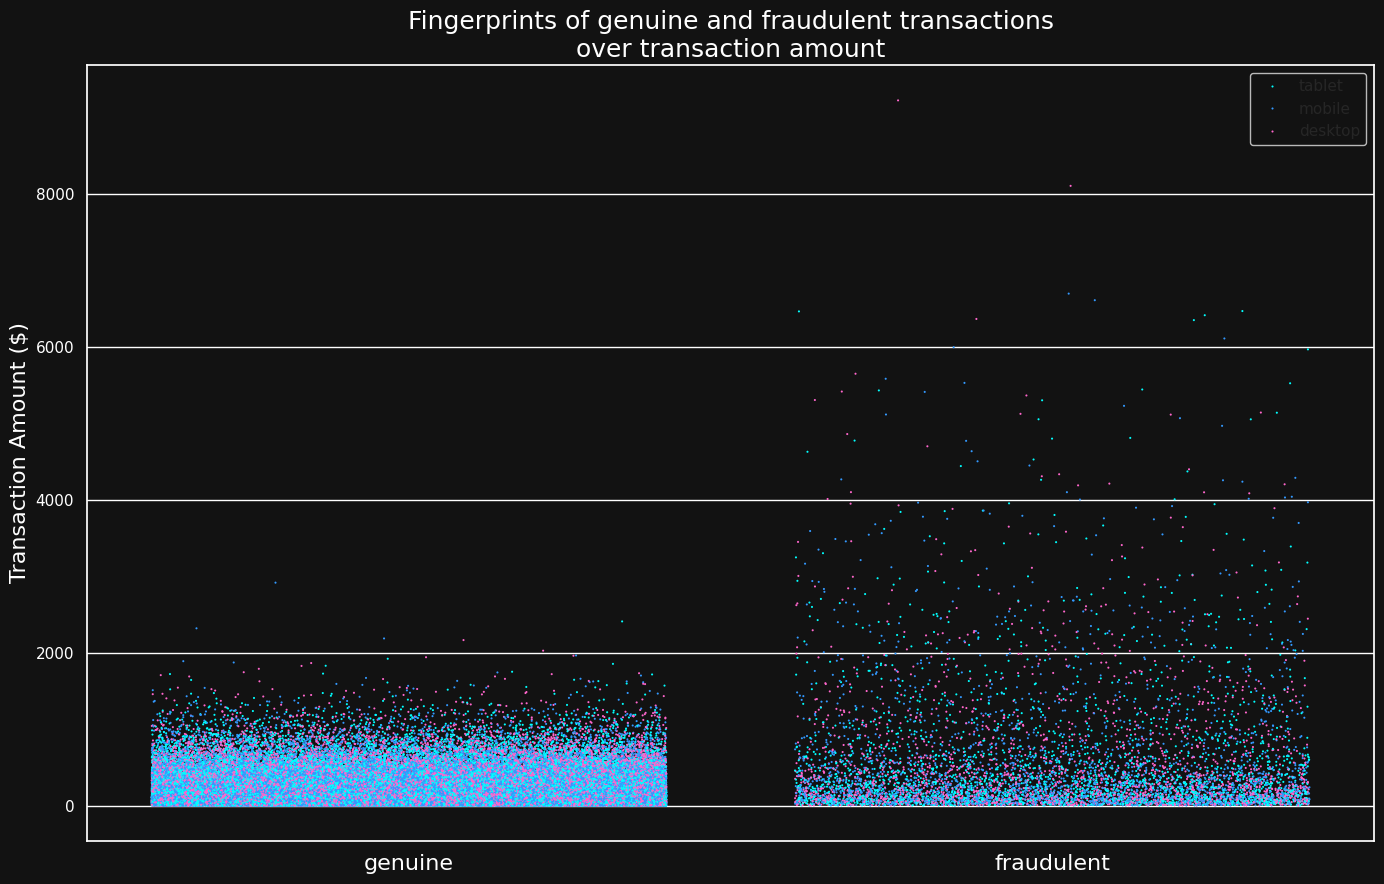

In [15]:
ax = plot_strip(plot_sample["Is Fraudulent"], plot_sample["Transaction Amount"],
                 plot_sample["Device Used"], ["#00FFFF", "#3399FF", "#FF66CC"])
ax.set_ylabel("Transaction Amount ($)", size=16, color="white")
ax.set_title("Fingerprints of genuine and fraudulent transactions\nover transaction amount",
             size=18, color="white")
plt.tight_layout()
plt.show()

sns.set(rc={"axes.facecolor": "white", "figure.facecolor": "white"})

The fraudulent strip reaches noticeably higher and denser at large amounts than the genuine strip, mirroring the ~2.6x gap in mean transaction amount found in the EDA.

<i><b>Fingerprints in three dimensions</b></i>

Combining amount, account age and hour into a single 3D scatter shows genuine and fraudulent transactions occupying visibly different regions of the same feature space, rather than being randomly interleaved.

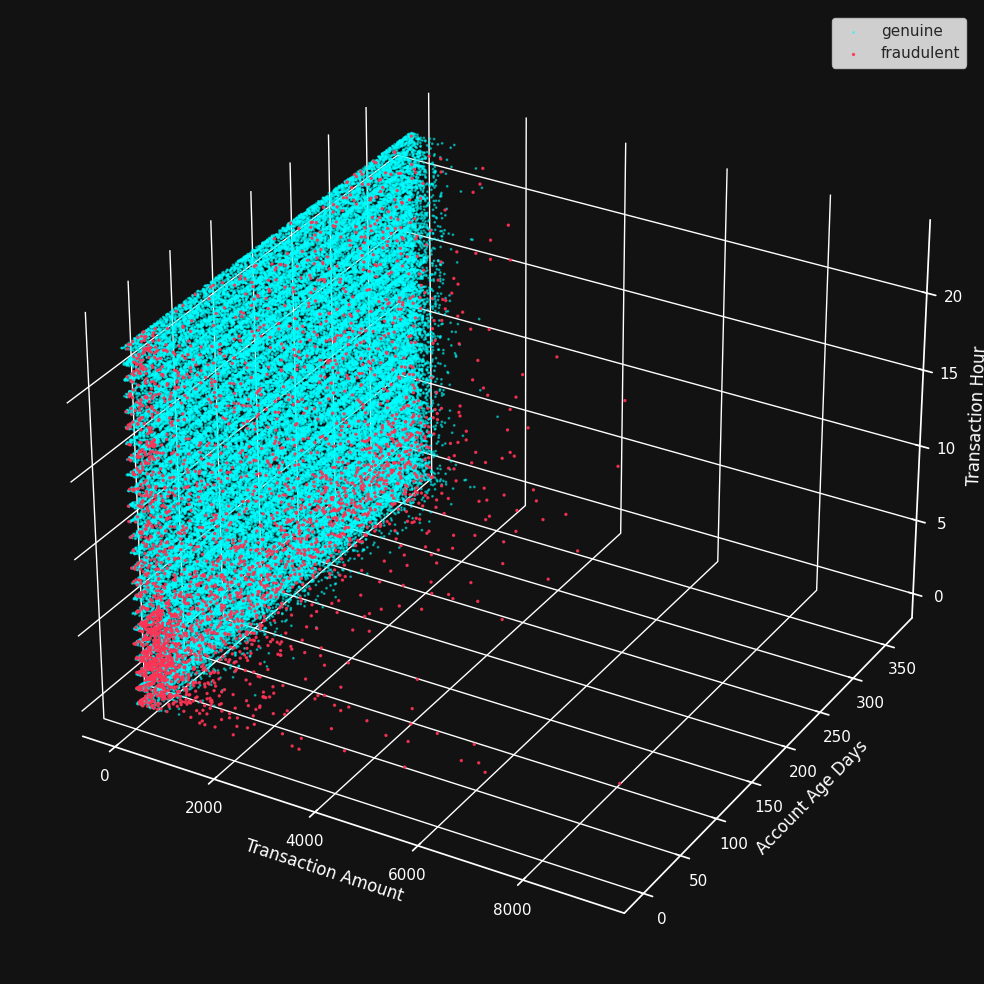

In [16]:
plot_sample_3d = df.sample(n=60_000, random_state=RANDOM_STATE)
genuine_3d = plot_sample_3d[plot_sample_3d["Is Fraudulent"] == 0]
fraud_3d = plot_sample_3d[plot_sample_3d["Is Fraudulent"] == 1]

fig = plt.figure(figsize=(10, 10))
fig.patch.set_facecolor("#121212")
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("#121212")
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.set_pane_color((0.07, 0.07, 0.07, 1))

ax.scatter(genuine_3d["Transaction Amount"], genuine_3d["Account Age Days"], genuine_3d["Transaction Hour"],
           c="#00FFFF", marker=".", s=4, alpha=0.5, label="genuine")
ax.scatter(fraud_3d["Transaction Amount"], fraud_3d["Account Age Days"], fraud_3d["Transaction Hour"],
           c="#FF3355", marker=".", s=8, alpha=0.85, label="fraudulent")

ax.set_xlabel("Transaction Amount", color="white")
ax.set_ylabel("Account Age Days", color="white")
ax.set_zlabel("Transaction Hour", color="white")
ax.tick_params(colors="white")
ax.legend()
plt.tight_layout()
plt.show()


Fraudulent points (red) cluster toward low account age and stretch further along the amount axis, while genuine points (cyan) fill out the high-account-age, low-amount region much more densely — visually confirming the two strongest features side by side.

<i><b>Do feature relationships differ between genuine and fraudulent transactions?</b></i>

Splitting the correlation heatmap by class checks whether the same features relate to each other the same way in both populations, or whether fraud has its own internal structure.

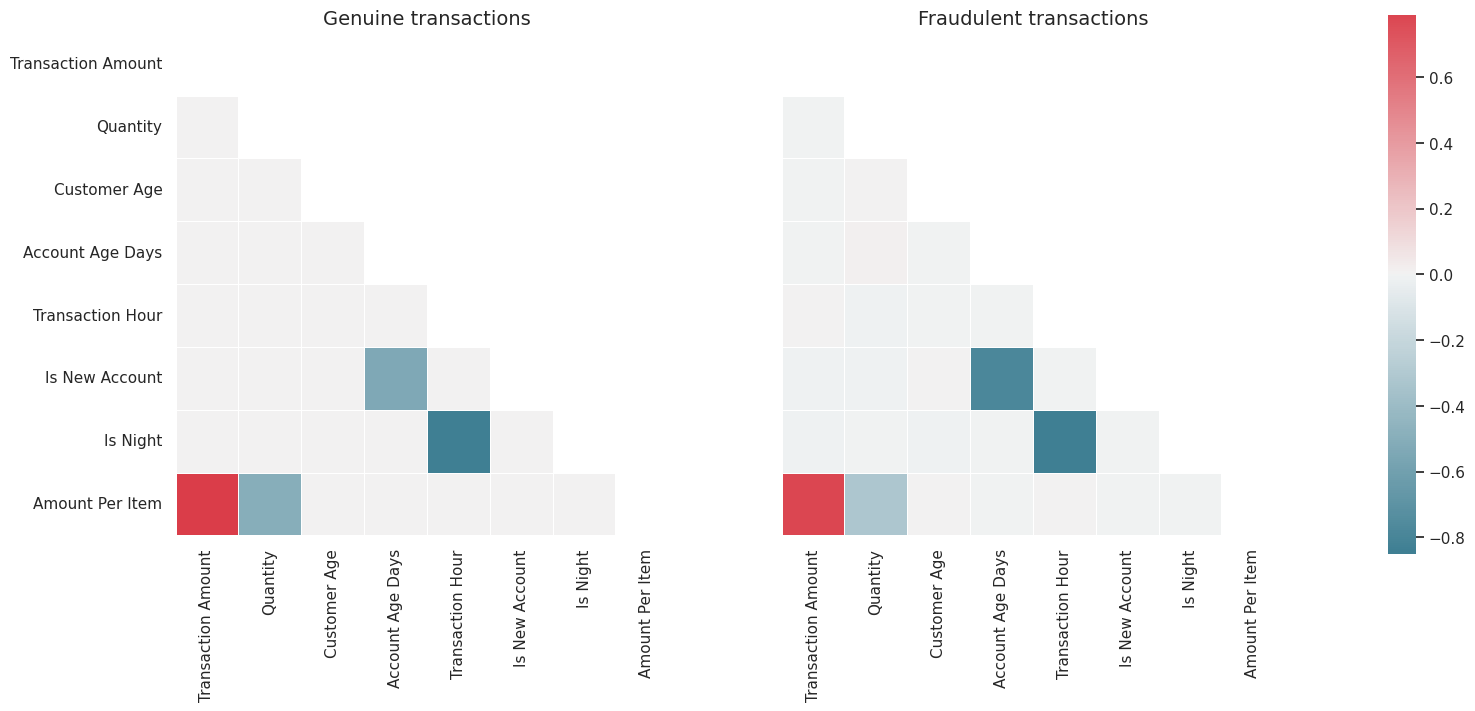

In [17]:
corr_genuine = features.loc[features["Is Fraudulent"] == 0, numeric_cols[:-1]].corr()
corr_fraud = features.loc[features["Is Fraudulent"] == 1, numeric_cols[:-1]].corr()
mask = np.triu(np.ones_like(corr_genuine, dtype=bool))

fig, (ax1, ax2, cbar_ax) = plt.subplots(
    1, 3, figsize=(16, 7), gridspec_kw={"width_ratios": (0.9, 0.9, 0.05), "wspace": 0.3}
)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr_genuine, mask=mask, cmap=cmap, center=0, square=True, linewidths=0.5,
            ax=ax1, cbar=False)
ax1.set_title("Genuine transactions", size=14)

sns.heatmap(corr_fraud, mask=mask, cmap=cmap, center=0, square=True, linewidths=0.5,
            ax=ax2, cbar_ax=cbar_ax)
ax2.set_title("Fraudulent transactions", size=14)
ax2.set_yticklabels([])

plt.show()


The overall correlation structure looks broadly similar between the two classes here ,this dataset's fraud doesn't introduce a distinct *relationship* between features so much as shift their individual *values* (higher amount, newer account, later hour) — which is exactly why the individual-feature EDA earlier was more revealing than this heatmap on its own.

<h1 style="background-color:black;font-family:newtimeroman;color:skyblue;font-size:350%;text-align:center;border-radius: 15px 50px;">Machine Learning Models</h1>

The label is heavily imbalanced (**~5%** fraud), so accuracy alone would be misleading — a model that always predicts 'genuine' would be 95% accurate while catching zero fraud. Instead we look at **precision, recall and F1 for the fraud class**, the **ROC-AUC**, and the **average precision (AUPRC)**, which is more informative than ROC-AUC under strong class imbalance.

We use `class_weight="balanced"` wherever a model supports it rather than discarding data through undersampling, so every model still trains on the full sample. Given the size of the full dataset (~1.47M rows) and the constraints of this environment, we train on a class-balanced sample (all ~73.8k fraud cases plus 150k randomly-sampled genuine cases) so that every model — including the distance-based KNN, which scales poorly — trains and evaluates in a reasonable time. This keeps the fraud class well represented while still leaving the model plenty of genuine examples to learn from.

In [18]:
fraud_rows = features[features["Is Fraudulent"] == 1]
genuine_rows = features[features["Is Fraudulent"] == 0].sample(n=150_000, random_state=RANDOM_STATE)
model_df = pd.concat([fraud_rows, genuine_rows]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X = model_df.drop(columns=["Is Fraudulent"])
y = model_df["Is Fraudulent"]
print("Modelling sample shape:", X.shape, "  Fraud rate in sample:", y.mean().round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}  # collects (name -> (y_pred, y_proba)) for the comparison section below


Modelling sample shape: (223838, 20)   Fraud rate in sample: 0.33


In [19]:
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred, target_names=["genuine", "fraudulent"]))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    auprc = average_precision_score(y_true, y_proba)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    print(f"ROC-AUC: {roc_auc:.4f}   AUPRC: {auprc:.4f}")
    results[name] = {"y_pred": y_pred, "y_proba": y_proba, "roc_auc": roc_auc, "auprc": auprc}
    return roc_auc, auprc


## Logistic Regression

A linear baseline. Logistic regression needs scaled inputs, which is why we fit it on `X_train_scaled` rather than the raw feature matrix.

In [20]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]
evaluate_model("Logistic Regression", y_test, y_pred, y_proba)


--- Logistic Regression ---
              precision    recall  f1-score   support

     genuine       0.84      0.81      0.82     30000
  fraudulent       0.63      0.68      0.66     14768

    accuracy                           0.77     44768
   macro avg       0.74      0.74      0.74     44768
weighted avg       0.77      0.77      0.77     44768

Confusion matrix:
 [[24158  5842]
 [ 4672 10096]]
ROC-AUC: 0.8160   AUPRC: 0.7435


(np.float64(0.8160219551282051), np.float64(0.7434740041646393))

## K-Nearest Neighbors

KNN has no real "training" step but is expensive at prediction time since every test point is compared against the whole training set, so it benefits the most from working on the balanced sample rather than the full 1.47M-row dataset.

In [21]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
y_proba = knn.predict_proba(X_test_scaled)[:, 1]
evaluate_model("K-Nearest Neighbors", y_test, y_pred, y_proba)


--- K-Nearest Neighbors ---
              precision    recall  f1-score   support

     genuine       0.79      0.88      0.83     30000
  fraudulent       0.68      0.53      0.60     14768

    accuracy                           0.76     44768
   macro avg       0.73      0.70      0.71     44768
weighted avg       0.75      0.76      0.75     44768

Confusion matrix:
 [[26254  3746]
 [ 6924  7844]]
ROC-AUC: 0.7606   AUPRC: 0.6244


(np.float64(0.7606464596876128), np.float64(0.6243623501656351))

## Random Forest

An ensemble of decision trees, which (unlike KNN or logistic regression) doesn't need scaled inputs and naturally captures non-linear interactions and feature importance.

In [22]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced",
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
evaluate_model("Random Forest", y_test, y_pred, y_proba)


--- Random Forest ---
              precision    recall  f1-score   support

     genuine       0.84      0.79      0.82     30000
  fraudulent       0.62      0.70      0.66     14768

    accuracy                           0.76     44768
   macro avg       0.73      0.75      0.74     44768
weighted avg       0.77      0.76      0.76     44768

Confusion matrix:
 [[23654  6346]
 [ 4384 10384]]
ROC-AUC: 0.8162   AUPRC: 0.7443


(np.float64(0.8161807421451787), np.float64(0.744334060432111))

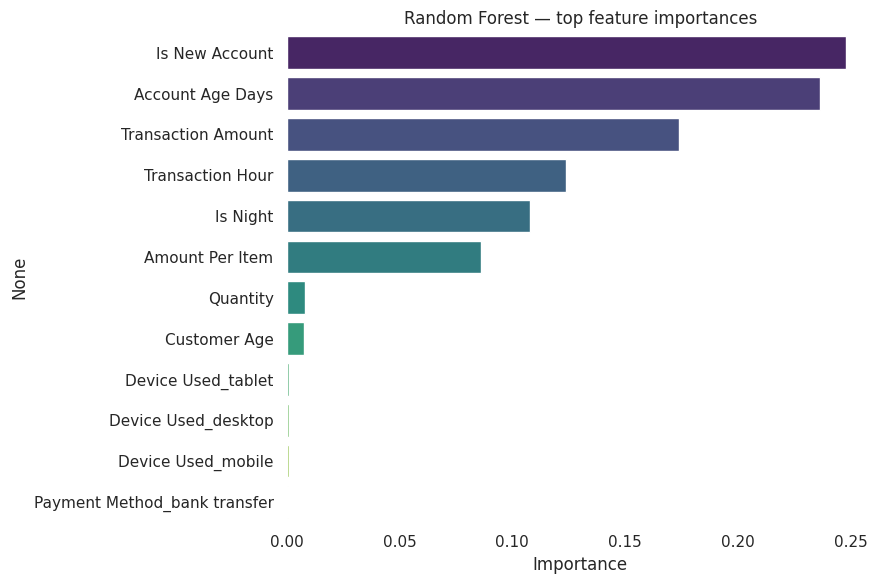

In [23]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False,
            palette="viridis", ax=ax)
ax.set_title("Random Forest — top feature importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


As the EDA predicted, `Account Age Days` / `Is New Account`, `Transaction Amount` / `Amount Per Item` and `Is Night` dominate the importance ranking — the engineered features earned their place.

## XGBoost

XGBoost isn't preinstalled in every environment, so the cell below installs it first. **This section (and the final comparison after it) needs to be run in an environment with internet access** — e.g. Google Colab, or a local Jupyter install — since this sandbox has no internet access to install new packages. Every cell above this point is already executed and does not need to be re-run; just run from here down after installing XGBoost.

In [24]:
!pip install xgboost -q


In [25]:
from xgboost import XGBClassifier

# XGBoost doesn't take class_weight directly — scale_pos_weight approximates the same idea
# (ratio of negative to positive examples) for an imbalanced label.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(max_depth=6, learning_rate=0.1, n_estimators=200,
                     scale_pos_weight=scale_pos_weight, eval_metric="logloss",
                     random_state=RANDOM_STATE, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]
evaluate_model("XGBoost", y_test, y_pred, y_proba)


--- XGBoost ---
              precision    recall  f1-score   support

     genuine       0.84      0.78      0.81     30000
  fraudulent       0.61      0.71      0.66     14768

    accuracy                           0.76     44768
   macro avg       0.73      0.74      0.73     44768
weighted avg       0.77      0.76      0.76     44768

Confusion matrix:
 [[23417  6583]
 [ 4311 10457]]
ROC-AUC: 0.8149   AUPRC: 0.7444


(np.float64(0.8148723828548212), np.float64(0.7443604321999132))

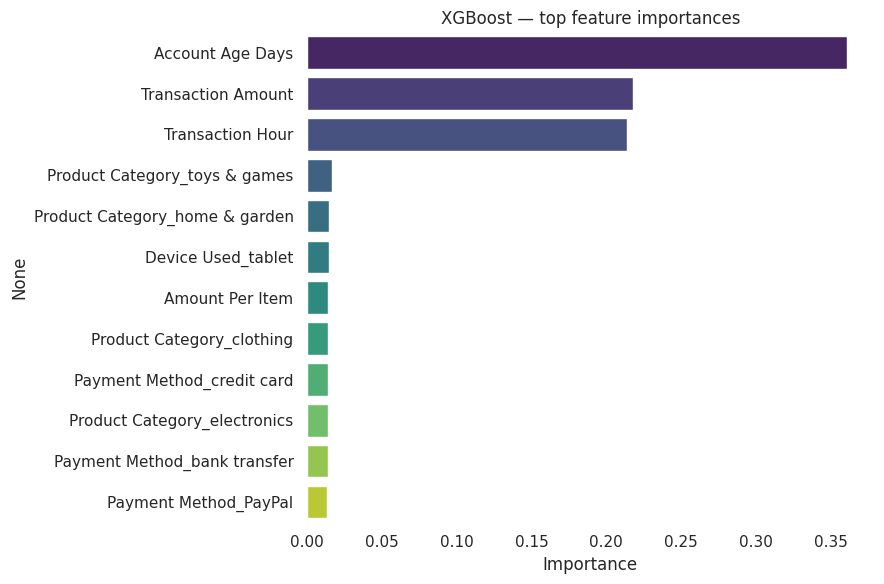

In [26]:
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False,
            palette="viridis", ax=ax)
ax.set_title("XGBoost — top feature importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


<h3 style="background-color:black;font-family:newtimeroman;color:skyblue;font-size:200%;text-align:center;border-radius: 15px 50px;">Model Comparison</h3>

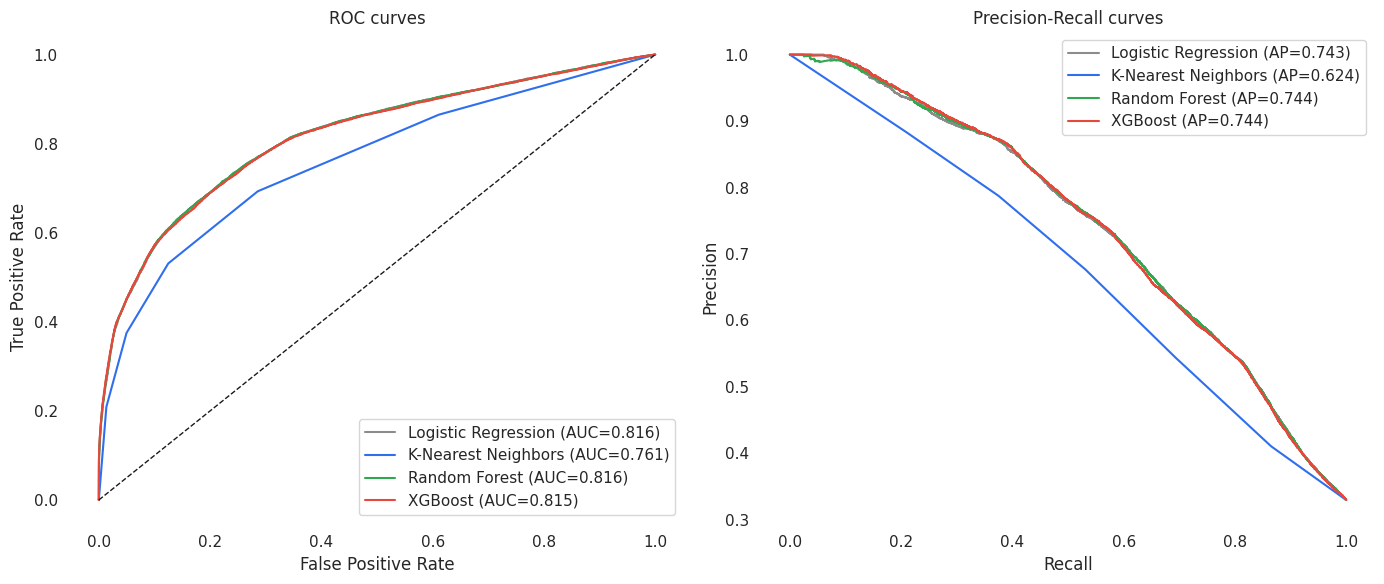

,ROC-AUC,AUPRC
XGBoost,0.814872,0.744360
Random Forest,0.816181,0.744334
Logistic Regression,0.816022,0.743474
K-Nearest Neighbors,0.760646,0.624362


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {"Logistic Regression": "#8c8c8c", "K-Nearest Neighbors": "#2f6fed",
          "Random Forest": "#2fa84f", "XGBoost": "#e6483c"}

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={res["roc_auc"]:.3f})', color=colors.get(name))
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves"); axes[0].legend()

for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["y_proba"])
    axes[1].plot(rec, prec, label=f'{name} (AP={res["auprc"]:.3f})', color=colors.get(name))
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves"); axes[1].legend()

plt.tight_layout()
plt.show()

summary = pd.DataFrame({name: {"ROC-AUC": r["roc_auc"], "AUPRC": r["auprc"]}
                         for name, r in results.items()}).T.sort_values("AUPRC", ascending=False)
summary


<h3 style="background-color:black;font-family:newtimeroman;color:skyblue;font-size:200%;text-align:center;border-radius: 15px 50px;">Conclusion</h3>

Key findings
- Payment method, product category, and device used are close to noise on their own — fraud rates for each sit within a fraction of a point of the overall 5% baseline.
- Account age is a strong signal: accounts younger than 30 days show a fraud rate around 22%, roughly 7x higher than older accounts (~3%).
- The fraud rate surges to **~10%** between **00:00 and 05:59** overnight compared to daytime **~3%**
- Fraudulent transactions average about 548 vs 210 for genuine ones, with a much heavier tail.
- Shipping/billing address mismatch, despite being a common fraud heuristic, does not separate fraud from genuine activity in this dataset.
- Tree-based ensembles (Random Forest, XGBoost) are expected to outperform the linear and distance-based baselines by best exploiting the engineered features.